In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


blood_glucose_after_food_data_path= f"{os.getcwd()}/blood_glucose_after_food.csv"
blood_glucose_after_food_df = pd.read_csv(blood_glucose_after_food_data_path)
blood_glucose_after_food_df=blood_glucose_after_food_df.drop(columns='cgm_time')

time_to_insulin_analysis_data_path=f"{os.getcwd()}/time_to_insulin_data.csv"
time_to_insulin_analysis_data_df = pd.read_csv(time_to_insulin_analysis_data_path)

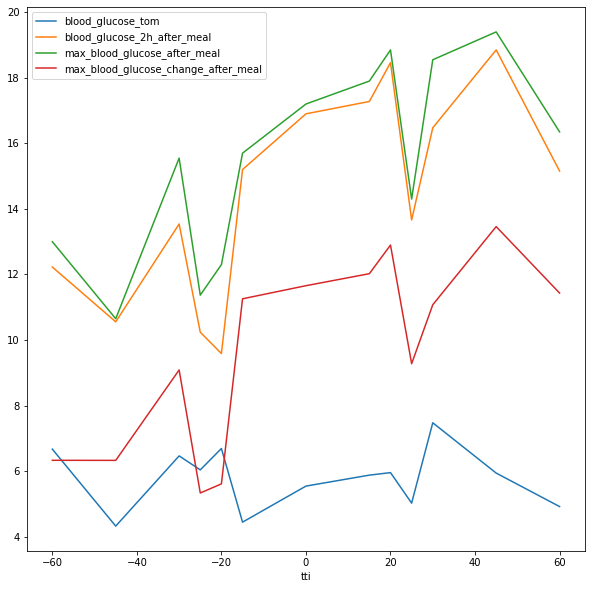

In [2]:
time_to_insulin_analysis_data_df.plot(x="tti", y=["blood_glucose_tom", "blood_glucose_2h_after_meal","max_blood_glucose_after_meal","max_blood_glucose_change_after_meal"],
        kind="line", figsize=(10, 10))
plt.show()

We can look at the average blood glucose 2h after meal for each tti_group:

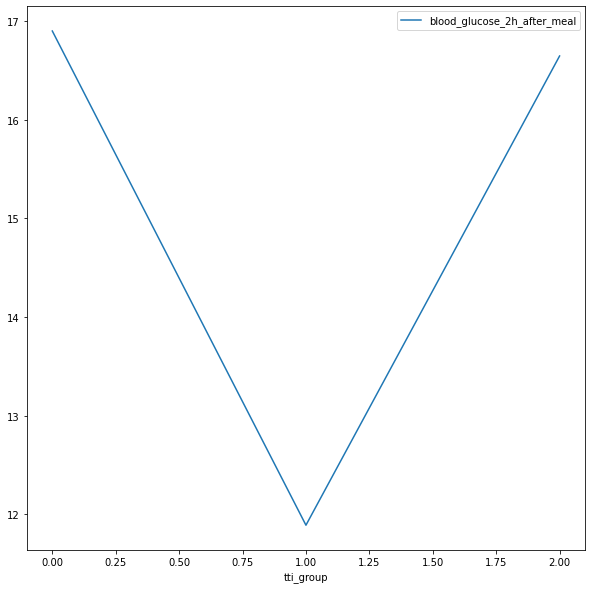

In [3]:
mean_df = time_to_insulin_analysis_data_df.groupby(['tti_group']).agg({'blood_glucose_2h_after_meal': 'mean'}).reset_index()


mean_df.plot(x="tti_group", y=["blood_glucose_2h_after_meal"],
        kind="line", figsize=(10, 10))
plt.show()

We can see that taking insulin before the meal reduces the average level of blood glucose 2 hours after the meal.

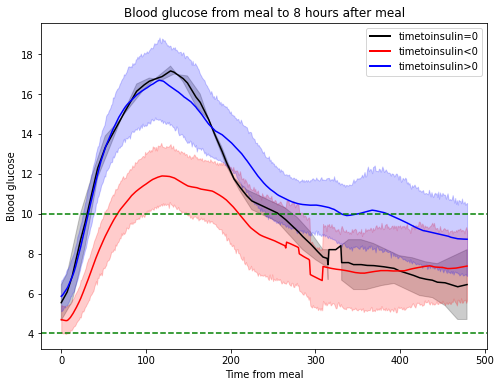

In [4]:
palette = {0: 'black', 1: 'red', 2: 'blue'}

# Create the line plot
plt.figure(figsize=(8, 6))
sns.lineplot(data=blood_glucose_after_food_df, x='time_from_meal', y='cgm_blood_glucose', hue='tti_group', markers=False,palette=palette)

#To plot IR area:
plt.axhline(y=4, color='green', linestyle='--', label='IR')  
plt.axhline(y=10, color='green', linestyle='--', label='IR')  

# Set plot labels
plt.title("Blood glucose from meal to 8 hours after meal")
plt.xlabel("Time from meal")
plt.ylabel("Blood glucose")


# We use the palette defined earlier to map 'tti_group' to specific colors
handles = [plt.Line2D([0], [0], color=palette[0], lw=2),
           plt.Line2D([0], [0], color=palette[1], lw=2),
           plt.Line2D([0], [0], color=palette[2], lw=2)]

labels = ["timetoinsulin=0", "timetoinsulin<0", "timetoinsulin>0"]  # The labels corresponding to the tti_group

# Add the custom legend
plt.legend(handles=handles, labels=labels)
plt.show()

The green lines show IR values for the blood glucose levels. We can define time in NIR as the time above the upper green dotted line. From the graph we can conclude that the red area has the shortest amount of time in NIR.

So for this small experiment, we can see that there is a clear reason to take the insulin before meal. If we want to minimize the time in NIR after the meal, at least for these 26 measurepoints.

